# Japan Protein Cost-Efficiency Analysis
## Notebook 01 — USDA SR Legacy: Load & Explore

**Project goal:** Identify the most cost-efficient, high-quality protein sources available in Japan.  
**Data source:** USDA SR Legacy (Standard Reference Legacy Release) — nutrient composition per 100g.  
**Author:** Anthony DiSorbo
**Last updated:** 2026-06

---

### What this notebook does
1. Mounts Google Drive and loads the USDA SR Legacy CSV files
2. Explores the schema and identifies the relevant nutrient codes
3. Filters to the 31 protein sources in scope
4. Extracts protein (g/100g) and energy (kcal/100g) for each food
5. Exports a clean `nutrients_base.csv` for the next notebook (price join)

### USDA SR Legacy file structure
The dataset ships as several pipe-delimited `.txt` files. Key files:
| File | Contents |
|---|---|
| `FOOD_DES.txt` | Food descriptions and IDs |
| `NUT_DATA.txt` | Nutrient values per 100g |
| `NUTR_DEF.txt` | Nutrient definitions (codes → names) |
| `WEIGHT.txt` | Common household measures |

> **Download:** https://fdc.nal.usda.gov/download-datasets.html → "SR Legacy" zip

---
## 0. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Libraries loaded ✓')

Libraries loaded ✓


In [ ]:
from google.colab import auth
auth.authenticate_user()

from google.auth import default
from googleapiclient.discovery import build
import io, os
from pathlib import Path

creds, _ = default()
service = build('drive', 'v3', credentials=creds)

OUTPUT_DIR = Path('/content/charts')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Drive service ready ✓')

Drive service ready ✓


In [ ]:
from google.colab import auth
auth.authenticate_user()

from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload
import io, os

creds, _ = __import__('google.auth', fromlist=['default']).default()
service = build('drive', 'v3', credentials=creds)

# List files in your sr_legacy_food folder
results = service.files().list(
    q="name contains '.csv' and trashed=false",
    fields="files(id, name)"
).execute()

for f in results['files']:
    print(f['name'], '|', f['id'])

nutrients_diaas.csv | 1ncwWqvXYtGYZhW_FrGZmkrKK4aknaRNK
nutrients_diaas.csv | 1BstzSJvn0Ki1bmHdj4Gm0OLPHAts8N0B
nutrients_prices.csv | 1xuea6ACqrEshZ4nErX0PjzT-ewa2GJI_
nutrients_prices.csv | 1RGsHGcA78fB9vTeFP_iWgpYJdr0pwQaX
nutrients_base.csv | 1qMUqP1Pc4NqzbteRGvDUUEzftP0ZBJcs
nutrients_base.csv | 19_b2NKf2HvaPrSjf_kwFqq48me3i0Rg0
nutrients_prices.csv | 19ztwX1-HLaOMi-TCgd8-4pUdgdR6R5Uw
nutrients_prices.csv | 19G6dYlJ5YAi6GPaR364xos9Gd6cAtTGL
nutrients_prices.csv | 1rX_lQ-Rb7yacj36pGAUyu5WiIdXQXCp2
nutrients_base.csv | 11l6azviSH1wA0WJjmdwFkfHHEajyIa-e
nutrient.csv | 1y3W3FClUdxnSGUe3QpjYWdOM0rNE5WIx
food_protein_conversion_factor.csv | 13ldDV9FuL63KXPTSpOFvVgvoVPSmkiht
food_attribute.csv | 1yx1pMNXqalg0sUzsZk6TtomBTVknsJeu
food_calorie_conversion_factor.csv | 15hs4tVSROJSF7yYlQHX__QlmAUFGwz5_
food.csv | 10UHetV9sP1yCi26dNyM4wZWGt1iRt6mf
food_portion.csv | 1m5MRxcxWtz9b_43NGKaHTmEDfOYz7lem
food_nutrient_conversion_factor.csv | 1JgUrcv0rAGeBAN25ML2JbR_GmtCPtaq2
all_downloaded_table_r

In [ ]:
# Download the key files into Colab temp storage
FILES_TO_DOWNLOAD = {
    'food.csv':          '10UHetV9sP1yCi26dNyM4wZWGt1iRt6mf',
    'food_nutrient.csv': '1pwmbhKSc6ioCJduofZKMtrhgyHdjjdlE',
    'nutrient.csv':      '1y3W3FClUdxnSGUe3QpjYWdOM0rNE5WIx',
    'food_portion.csv':  '1m5MRxcxWtz9b_43NGKaHTmEDfOYz7lem',
}

LOCAL_DIR = '/content/sr_legacy/'
os.makedirs(LOCAL_DIR, exist_ok=True)

for filename, file_id in FILES_TO_DOWNLOAD.items():
    request = service.files().get_media(fileId=file_id)
    fh = io.FileIO(LOCAL_DIR + filename, 'wb')
    downloader = MediaIoBaseDownload(fh, request)
    done = False
    while not done:
        status, done = downloader.next_chunk()
    print(f'✓ {filename}')

print('\nAll files ready at', LOCAL_DIR)

✓ food.csv
✓ food_nutrient.csv
✓ nutrient.csv
✓ food_portion.csv

All files ready at /content/sr_legacy/


---
## 1. Load USDA SR Legacy Files

In [ ]:
# FoodData Central SR Legacy CSVs (standard comma-delimited)
LOCAL_DIR = '/content/sr_legacy/'

# Food descriptions
food_des = pd.read_csv(LOCAL_DIR + 'food.csv')

# Nutrient definitions
nutr_def = pd.read_csv(LOCAL_DIR + 'nutrient.csv')

# Nutrient values per 100g
nut_data = pd.read_csv(LOCAL_DIR + 'food_nutrient.csv')

print(f'food_des  : {food_des.shape[0]:,} rows')
print(f'nutr_def  : {nutr_def.shape[0]:,} rows')
print(f'nut_data  : {nut_data.shape[0]:,} rows')

# Preview column names — important for the next cell
print('\nfood_des columns  :', list(food_des.columns))
print('nutr_def columns  :', list(nutr_def.columns))
print('nut_data columns  :', list(nut_data.columns))

food_des  : 7,793 rows
nutr_def  : 474 rows
nut_data  : 644,125 rows

food_des columns  : ['fdc_id', 'data_type', 'description', 'food_category_id', 'publication_date']
nutr_def columns  : ['id', 'name', 'unit_name', 'nutrient_nbr', 'rank']
nut_data columns  : ['id', 'fdc_id', 'nutrient_id', 'amount', 'data_points', 'derivation_id', 'min', 'max', 'median', 'footnote', 'min_year_acquired']


In [ ]:
# Identify the nutrient codes we need
TARGET_NUTRIENTS = ['Protein', 'Energy', 'Total lipid (fat)', 'Carbohydrate, by difference', 'Water']
nutr_def[nutr_def['name'].isin(TARGET_NUTRIENTS)][['id', 'name', 'unit_name']]

,id,name,unit_name
4,1003,Protein,G
5,1004,Total lipid (fat),G
6,1005,"Carbohydrate, by difference",G
9,1008,Energy,KCAL
52,1051,Water,G
63,1062,Energy,kJ


In [ ]:
# Key nutrient codes in FoodData Central SR Legacy
NUTR_CODES = {
    1003: 'protein_g',
    1004: 'fat_g',
    1005: 'carbs_g',
    1008: 'energy_kcal',
    1051: 'water_g',
}

print('Nutrient codes confirmed:')
for code, name in NUTR_CODES.items():
    desc = nutr_def.loc[nutr_def['id'] == code, 'name'].values
    unit = nutr_def.loc[nutr_def['id'] == code, 'unit_name'].values
    print(f'  {code} → {name:20s} | {desc[0]} ({unit[0]})')

Nutrient codes confirmed:
  1003 → protein_g            | Protein (G)
  1004 → fat_g                | Total lipid (fat) (G)
  1005 → carbs_g              | Carbohydrate, by difference (G)
  1008 → energy_kcal          | Energy (KCAL)
  1051 → water_g              | Water (G)


---
## 2. Pivot Nutrients to Wide Format

In [ ]:
# Filter to only the nutrients we need, then pivot to one row per food
nut_filtered = nut_data[nut_data['nutrient_id'].isin(NUTR_CODES.keys())][['fdc_id', 'nutrient_id', 'amount']].copy()
nut_filtered['nutrient_id'] = nut_filtered['nutrient_id'].map(NUTR_CODES)

nutrients_wide = nut_filtered.pivot_table(
    index='fdc_id', columns='nutrient_id', values='amount', aggfunc='first'
).reset_index()

# Merge with food descriptions
df = food_des[['fdc_id', 'description']].merge(nutrients_wide, on='fdc_id', how='inner')

print(f'Full nutrient table: {df.shape[0]:,} foods × {df.shape[1]} columns')
df.head(3)

Full nutrient table: 7,793 foods × 7 columns


,fdc_id,description,carbs_g,energy_kcal,fat_g,protein_g,water_g
0,167512,"Pillsbury Golden Layer Buttermilk Biscuits, Artificial F...",41.18,307.00,13.24,5.88,35.50
1,167513,"Pillsbury, Cinnamon Rolls with Icing, refrigerated dough",53.42,330.00,11.27,4.34,27.86
2,167514,"Kraft Foods, Shake N Bake Original Recipe, Coating for P...",79.80,377.00,3.70,6.10,3.20


---
## 3. Map Project Foods → USDA Entries

This is the most important manual step. We search the USDA descriptions to find the best-matching entry for each of the 31 foods in scope. We prefer **raw, unprocessed, no added ingredients** entries where available.

In [ ]:
def search_food(query: str, top_n: int = 8) -> pd.DataFrame:
    """Case-insensitive substring search across description."""
    mask = df['description'].str.contains(query, case=False, na=False)
    cols = ['fdc_id', 'description', 'protein_g', 'energy_kcal', 'fat_g']
    return df[mask][cols].head(top_n).reset_index(drop=True)

# Test it
search_food('chicken breast')

,fdc_id,description,protein_g,energy_kcal,fat_g
0,171514,"Chicken breast tenders, breaded, cooked, microwaved",16.35,252.00,12.89
1,171515,"Chicken breast tenders, breaded, uncooked",14.73,263.00,15.75
2,172945,"Oscar Mayer, Chicken Breast (honey glazed)",19.85,109.00,1.50
3,172962,"Chicken breast, fat-free, mesquite flavor, sliced",16.80,80.00,0.39
4,172963,"Chicken breast, oven-roasted, fat-free, sliced",16.79,79.00,0.39
5,173874,"Chicken breast, deli, rotisserie seasoned, sliced, prepa...",17.40,98.00,1.86
6,174608,"Chicken breast, roll, oven-roasted",14.59,134.00,7.65


The protein counts for these foods are suspiciously low. They are likely processed chicken breast, not raw or whole food chicken breast.

In [ ]:
#Retest with different terms
search_food('chicken, broilers or fryers, breast')

,fdc_id,description,protein_g,energy_kcal,fat_g
0,171075,"Chicken, broilers or fryers, breast, meat and skin, cook...",29.80,197.00,7.78
1,171076,"Chicken, broilers or fryers, breast, meat and skin, cook...",27.39,184.00,7.42
2,171078,"Chicken, broilers or fryers, breast, meat only, cooked, ...",33.44,187.00,4.71
3,171474,"Chicken, broilers or fryers, breast, meat and skin, raw",20.85,172.00,9.25
4,171475,"Chicken, broilers or fryers, breast, meat and skin, cook...",24.84,260.00,13.20
5,171476,"Chicken, broilers or fryers, breast, meat and skin, cook...",31.84,222.00,8.87
6,171477,"Chicken, broilers or fryers, breast, meat only, cooked, ...",31.02,165.00,3.57
7,171478,"Chicken, broilers or fryers, breast, meat only, cooked, ...",28.98,151.00,3.03


In [ ]:
searches = {
    'chicken_thigh':    'chicken, broilers or fryers, thigh',
    'chicken_sasami':   'chicken, broilers or fryers, breast, meat only',
    'chicken_wing':     'chicken, broilers or fryers, wing',
    'canned_chicken':   'chicken, canned',
    'pork_loin':        'pork, fresh, loin',
    'beef_loin':        'beef, loin',
    'salmon':           'salmon, atlantic, wild',
    'mackerel':         'mackerel, atlantic',
    'squid':            'squid, mixed species',
    'white_fish':       'fish, cod, pacific',
    'tuna_fresh':       'tuna',
    'canned_tuna':      'tuna, light, canned in water',
    'natto':            'natto',
    'tofu_momen':       'tofu, firm',
    'tofu_kinu':        'tofu, soft',
    'egg_chicken':      'egg, whole, raw',
    'egg_quail':        'egg, quail',
    'milk':             'milk, whole',
    'yogurt_plain':     'yogurt, plain, whole milk',
    'greek_yogurt':     'yogurt, greek',
    'whey_protein':     'whey protein',
    'soy_protein':      'soy protein',
    'edamame':          'edamame',
}

for key, query in searches.items():
    print(f'\n=== {key} — search: "{query}" ===')
    print(search_food(query, top_n=10).to_string(index=False))


=== chicken_thigh — search: "chicken, broilers or fryers, thigh" ===
 fdc_id                                                              description  protein_g  energy_kcal  fat_g
 172385                   Chicken, broilers or fryers, thigh, meat and skin, raw      16.52       221.00  16.61
 172386 Chicken, broilers or fryers, thigh, meat and skin, cooked, fried, batter      21.61       277.00  16.53
 172387             Chicken, broilers or fryers, thigh, meat only, cooked, fried      28.18       218.00  10.30
 172388           Chicken, broilers or fryers, thigh, meat only, cooked, roasted      24.76       179.00   8.15
 172389            Chicken, broilers or fryers, thigh, meat only, cooked, stewed      25.00       195.00   9.79
 173624  Chicken, broilers or fryers, thigh, meat and skin, cooked, fried, flour      26.75       262.00  14.98
 173625       Chicken, broilers or fryers, thigh, meat and skin, cooked, roasted      23.26       232.00  14.71
 173626        Chicken, broilers o

In [ ]:
# ============================================================
# FOOD MAPPING TABLE
# Rule: raw, meat only, no skin/bone where available.
# Proxies and limitations documented in notes.
# ============================================================

FOOD_MAP = [
    # food_key                  fdc_id   notes
    ('chicken_breast',          171474, 'Chicken breast, meat and skin, raw — no meat-only raw entry in USDA'),
    ('chicken_thigh',           172385, 'Chicken thigh, meat and skin, raw'),
    ('chicken_sasami',          171474, 'PROXY: breast meat and skin, raw — sasami is leaner; slightly understates protein'),
    ('chicken_wing_tip',        172390, 'Chicken wing, meat and skin, raw'),
    ('chicken_wing_moto',       172390, 'PROXY: same as wing tip — no separate moto entry in USDA'),
    ('canned_chicken',          171110, 'Chicken, canned, no broth'),
    ('pork_tonkatsu',           167818, 'Pork loin, whole, lean and fat, raw'),
    ('pork_shougayaki',         167818, 'PROXY: pork loin, raw — thin cut not separately listed'),
    ('pork_shabushabu',         167818, 'PROXY: pork loin, raw — thin cut not separately listed'),
    ('pork_loin',               167818, 'Pork loin, whole, lean and fat, raw'),
    ('beef_american_cab',       168719, 'Beef, top loin, lean and fat, select, raw'),
    ('beef_wagyu_steak',        168719, 'PROXY: USDA top loin, select, raw — no wagyu entry; fat content understated'),
    ('beef_loin',               168719, 'Beef, top loin, lean and fat, select, raw'),
    ('beef_usugiri',            168719, 'PROXY: top loin, raw — thin-sliced not separately listed'),
    ('fresh_salmon',            173686, 'Salmon, Atlantic, wild, raw'),
    ('fresh_mackerel',          175119, 'Mackerel, Atlantic, raw'),
    ('fresh_squid',             174223, 'Squid, mixed species, raw'),
    ('fresh_white_fish',        174191, 'Cod, Pacific, raw — proxy for generic white fish'),
    ('fresh_tuna',              173706, 'Tuna, bluefin, raw'),
    ('canned_tuna',             171986, 'Tuna, light, canned in water, no salt, drained'),
    ('natto',                   172443, 'Natto'),
    ('tofu_momen',              172448, 'Tofu, firm, prepared with calcium sulfate and nigari'),
    ('tofu_kinu',               172449, 'Tofu, soft, prepared with calcium sulfate and nigari'),
    ('chicken_egg',             171287, 'Egg, whole, raw, fresh'),
    ('quail_egg',               172191, 'Egg, quail, whole, fresh, raw'),
    ('milk_whole',              171265, 'Milk, whole, 3.25% milkfat, with vitamin D'),
    ('yogurt_plain',            171284, 'Yogurt, plain, whole milk'),
    ('greek_yogurt',            170903, 'Yogurt, Greek, plain, lowfat'),
    ('whey_protein',            173177, 'Whey protein powder isolate'),
    ('soy_protein',             174276, 'Soy protein isolate'),
    ('edamame',                 168411, 'Edamame, frozen, prepared'),
]

food_map_df = pd.DataFrame(FOOD_MAP, columns=['food_key', 'fdc_id', 'usda_notes'])
print(f'{len(food_map_df)} foods mapped')
food_map_df

31 foods mapped


,food_key,fdc_id,usda_notes
0,chicken_breast,171474,"Chicken breast, meat and skin, raw — no meat-only raw en..."
1,chicken_thigh,172385,"Chicken thigh, meat and skin, raw"
2,chicken_sasami,171474,"PROXY: breast meat and skin, raw — sasami is leaner; sli..."
3,chicken_wing_tip,172390,"Chicken wing, meat and skin, raw"
4,chicken_wing_moto,172390,PROXY: same as wing tip — no separate moto entry in USDA
5,canned_chicken,171110,"Chicken, canned, no broth"
6,pork_tonkatsu,167818,"Pork loin, whole, lean and fat, raw"
7,pork_shougayaki,167818,"PROXY: pork loin, raw — thin cut not separately listed"
8,pork_shabushabu,167818,"PROXY: pork loin, raw — thin cut not separately listed"
9,pork_loin,167818,"Pork loin, whole, lean and fat, raw"


---
## 4. Build the Scoped Nutrient Table

In [ ]:
# Join the map onto the nutrient data
nutrients_scoped = food_map_df.merge(
    df[['fdc_id', 'description', 'protein_g', 'energy_kcal', 'fat_g', 'carbs_g', 'water_g']],
    on='fdc_id', how='left'
)

# Quick QA: flag any missing values
missing = nutrients_scoped[nutrients_scoped['protein_g'].isna()]
if not missing.empty:
    print('⚠️  Missing protein data — check fdc_id for these foods:')
    print(missing[['food_key', 'fdc_id']].to_string(index=False))
else:
    print(f'✓ All {len(nutrients_scoped)} foods have protein data')

nutrients_scoped[['food_key', 'description', 'protein_g', 'energy_kcal', 'fat_g']]

✓ All 31 foods have protein data


,food_key,description,protein_g,energy_kcal,fat_g
0,chicken_breast,"Chicken, broilers or fryers, breast, meat and skin, raw",20.85,172.00,9.25
1,chicken_thigh,"Chicken, broilers or fryers, thigh, meat and skin, raw",16.52,221.00,16.61
2,chicken_sasami,"Chicken, broilers or fryers, breast, meat and skin, raw",20.85,172.00,9.25
3,chicken_wing_tip,"Chicken, broilers or fryers, wing, meat and skin, raw",17.52,191.00,12.85
4,chicken_wing_moto,"Chicken, broilers or fryers, wing, meat and skin, raw",17.52,191.00,12.85
5,canned_chicken,"Chicken, canned, no broth",25.30,185.00,8.10
6,pork_tonkatsu,"Pork, fresh, loin, whole, separable lean and fat, raw",19.74,198.00,12.58
7,pork_shougayaki,"Pork, fresh, loin, whole, separable lean and fat, raw",19.74,198.00,12.58
8,pork_shabushabu,"Pork, fresh, loin, whole, separable lean and fat, raw",19.74,198.00,12.58
9,pork_loin,"Pork, fresh, loin, whole, separable lean and fat, raw",19.74,198.00,12.58


---
## 5. Exploratory Analysis

In [ ]:
print('=== Summary Statistics (per 100g) ===')
nutrients_scoped[['protein_g','energy_kcal','fat_g']].describe().round(1)

=== Summary Statistics (per 100g) ===


,protein_g,energy_kcal,fat_g
count,31.00,31.00,31.00
mean,20.50,169.30,8.50
std,15.70,73.40,5.20
min,3.20,61.00,0.40
25%,14.20,118.50,3.50
50%,19.70,185.00,9.20
75%,20.60,208.00,12.70
max,88.30,359.00,16.60


In [ ]:
# Protein density = protein_g / energy_kcal * 100 (protein kcal per total kcal)
# This is a common metric for 'protein quality per calorie'
nutrients_scoped['protein_pct_kcal'] = (nutrients_scoped['protein_g'] * 4 / nutrients_scoped['energy_kcal'] * 100).round(1)

nutrients_scoped.sort_values('protein_g', ascending=False)[
    ['food_key','protein_g','energy_kcal','protein_pct_kcal']
].reset_index(drop=True)

,food_key,protein_g,energy_kcal,protein_pct_kcal
0,soy_protein,88.32,335.00,105.50
1,whey_protein,58.14,359.00,64.80
2,canned_tuna,25.51,116.00,88.00
3,canned_chicken,25.30,185.00,54.70
4,fresh_tuna,23.33,144.00,64.80
5,chicken_sasami,20.85,172.00,48.50
6,chicken_breast,20.85,172.00,48.50
7,beef_wagyu_steak,20.59,224.00,36.80
8,beef_loin,20.59,224.00,36.80
9,beef_usugiri,20.59,224.00,36.80


In [ ]:
from pathlib import Path

OUTPUT_DIR = Path('/content/charts')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Output dir: {OUTPUT_DIR}')

Output dir: /content/charts


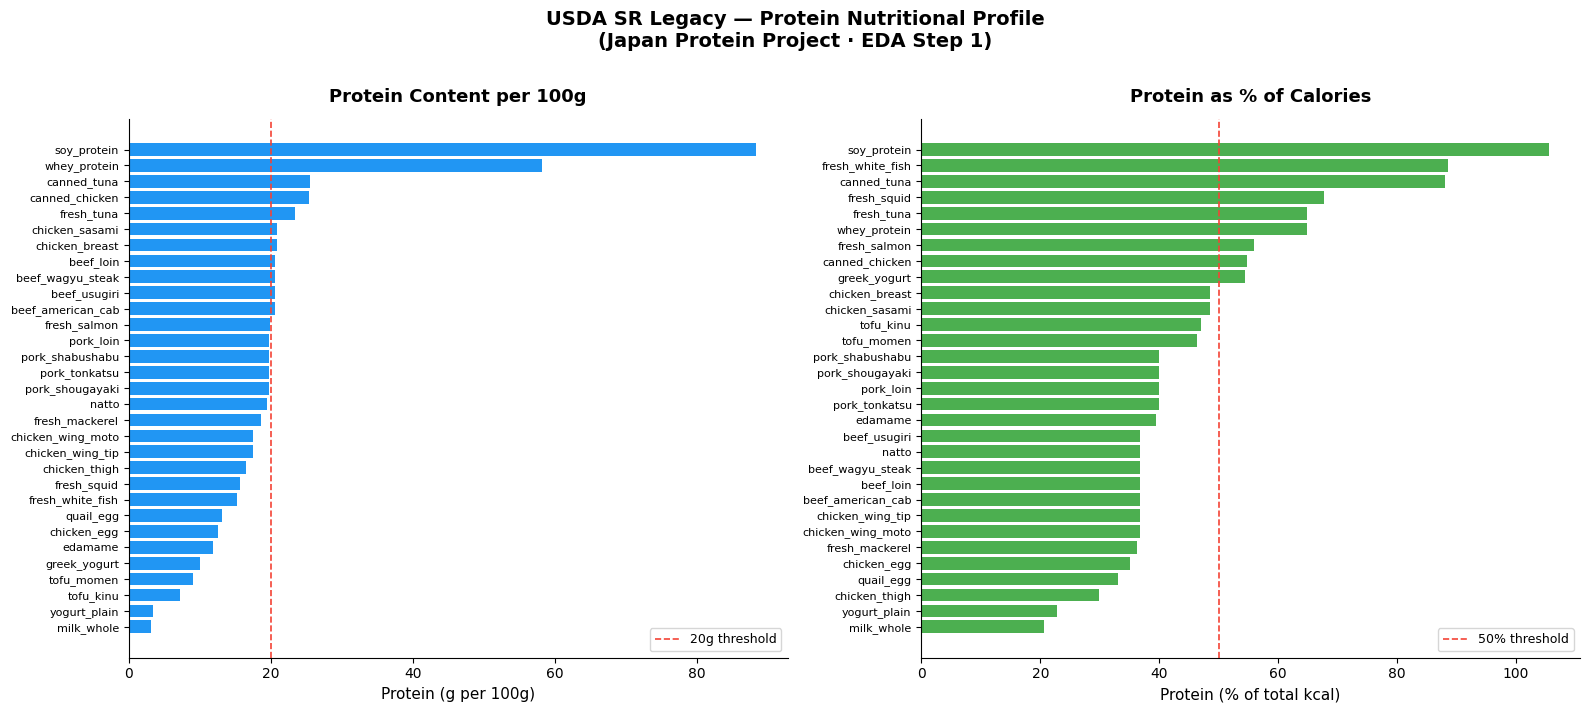

Chart saved ✓


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Chart 1: Protein per 100g ---
ax1 = axes[0]
plot_df = nutrients_scoped.sort_values('protein_g', ascending=True)
bars = ax1.barh(plot_df['food_key'], plot_df['protein_g'], color='#2196F3', edgecolor='none')
ax1.set_xlabel('Protein (g per 100g)', fontsize=11)
ax1.set_title('Protein Content per 100g', fontsize=13, fontweight='bold', pad=12)
ax1.axvline(x=20, color='#F44336', linestyle='--', linewidth=1.2, label='20g threshold')
ax1.legend(fontsize=9)
ax1.tick_params(axis='y', labelsize=8)
ax1.spines[['top','right']].set_visible(False)

# --- Chart 2: Protein % of kcal ---
ax2 = axes[1]
plot_df2 = nutrients_scoped.sort_values('protein_pct_kcal', ascending=True)
ax2.barh(plot_df2['food_key'], plot_df2['protein_pct_kcal'], color='#4CAF50', edgecolor='none')
ax2.set_xlabel('Protein (% of total kcal)', fontsize=11)
ax2.set_title('Protein as % of Calories', fontsize=13, fontweight='bold', pad=12)
ax2.axvline(x=50, color='#F44336', linestyle='--', linewidth=1.2, label='50% threshold')
ax2.legend(fontsize=9)
ax2.tick_params(axis='y', labelsize=8)
ax2.spines[['top','right']].set_visible(False)

plt.suptitle('USDA SR Legacy — Protein Nutritional Profile\n(Japan Protein Project · EDA Step 1)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_protein_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

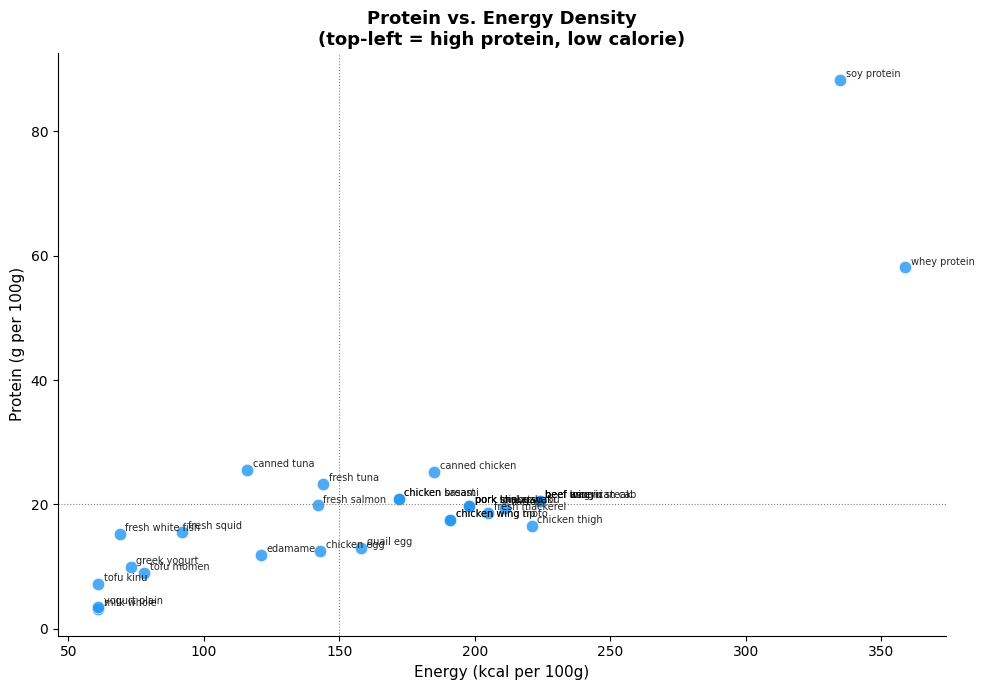

In [ ]:
# Scatter: protein vs energy — ideal foods are top-left (high protein, low kcal)
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    nutrients_scoped['energy_kcal'],
    nutrients_scoped['protein_g'],
    s=80, alpha=0.8, color='#2196F3', edgecolors='white', linewidths=0.5
)

for _, row in nutrients_scoped.iterrows():
    ax.annotate(row['food_key'].replace('_', ' '),
                xy=(row['energy_kcal'], row['protein_g']),
                xytext=(4, 2), textcoords='offset points', fontsize=7, alpha=0.85)

ax.set_xlabel('Energy (kcal per 100g)', fontsize=11)
ax.set_ylabel('Protein (g per 100g)', fontsize=11)
ax.set_title('Protein vs. Energy Density\n(top-left = high protein, low calorie)',
             fontsize=13, fontweight='bold')
ax.spines[['top','right']].set_visible(False)

# Quadrant reference lines
ax.axhline(y=20, color='gray', linestyle=':', linewidth=0.8)
ax.axvline(x=150, color='gray', linestyle=':', linewidth=0.8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_protein_vs_energy.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
results = service.files().list(
    q="name='food_data' and mimeType='application/vnd.google-apps.folder' and trashed=false",
    fields="files(id, name)"
).execute()

for f in results['files']:
    print(f['name'], '|', f['id'])

food_data | 17Jcona7Ur-iV7miakhLkhHGBgggT0to7


In [ ]:
from googleapiclient.http import MediaFileUpload

DRIVE_FOLDER_ID = '17Jcona7Ur-iV7miakhLkhHGBgggT0to7'

chart_files = [
    '/content/charts/eda_protein_profile.png',
    '/content/charts/eda_protein_vs_energy.png',
]

for chart_path in chart_files:
    filename = os.path.basename(chart_path)
    media = MediaFileUpload(chart_path, mimetype='image/png')
    file_metadata = {'name': filename, 'parents': [DRIVE_FOLDER_ID]}
    uploaded = service.files().create(body=file_metadata, media_body=media, fields='id, name').execute()
    print(f'✓ Uploaded {uploaded["name"]} (id: {uploaded["id"]})')

✓ Uploaded eda_protein_profile.png (id: 1IssWMohpgHlAt9qYQEN3TypZV3V-oFbm)
✓ Uploaded eda_protein_vs_energy.png (id: 1WDXq_4k10p2XhAZdEibIHjGEtUL6y6xf)


---
## 6. Export Clean Base Table

In [ ]:
# Add placeholder columns for later notebooks
nutrients_scoped['price_jpy_per_100g'] = np.nan   # → Notebook 02: supermarket prices
nutrients_scoped['diaas_score']         = np.nan   # → Notebook 03: FAO DIAAS scores
nutrients_scoped['source_category'] = nutrients_scoped['food_key'].apply(
    lambda x: 'poultry' if 'chicken' in x or 'quail' in x
         else 'pork'    if 'pork' in x
         else 'beef'    if 'beef' in x
         else 'seafood' if any(k in x for k in ['salmon','mackerel','squid','white_fish','tuna'])
         else 'dairy'   if any(k in x for k in ['milk','yogurt','whey'])
         else 'plant'
)

output_cols = [
    'food_key', 'source_category', 'fdc_id', 'description', 'usda_notes',
    'protein_g', 'energy_kcal', 'fat_g', 'carbs_g', 'water_g',
    'protein_pct_kcal', 'price_jpy_per_100g', 'diaas_score'
]

# Save locally
LOCAL_CSV = '/content/nutrients_base.csv'
nutrients_scoped[output_cols].to_csv(LOCAL_CSV, index=False)
print(f'Shape: {nutrients_scoped.shape[0]} rows × {len(output_cols)} columns')

# Upload to Drive
media = MediaFileUpload(LOCAL_CSV, mimetype='text/csv')
file_metadata = {'name': 'nutrients_base.csv', 'parents': [DRIVE_FOLDER_ID]}
uploaded = service.files().create(body=file_metadata, media_body=media, fields='id, name').execute()
print(f'✓ Uploaded {uploaded["name"]} (id: {uploaded["id"]})')

nutrients_scoped[output_cols].head()

Shape: 31 rows × 13 columns
✓ Uploaded nutrients_base.csv (id: 1Mo9mMb9f_c6s03ps2zwJHl_JP06UpP0T)


,food_key,source_category,fdc_id,description,usda_notes,protein_g,energy_kcal,fat_g,carbs_g,water_g,protein_pct_kcal,price_jpy_per_100g,diaas_score
0,chicken_breast,poultry,171474,"Chicken, broilers or fryers, breast, meat and skin, raw","Chicken breast, meat and skin, raw — no meat-only raw en...",20.85,172.00,9.25,0.00,69.46,48.50,NaN,NaN
1,chicken_thigh,poultry,172385,"Chicken, broilers or fryers, thigh, meat and skin, raw","Chicken thigh, meat and skin, raw",16.52,221.00,16.61,0.25,66.47,29.90,NaN,NaN
2,chicken_sasami,poultry,171474,"Chicken, broilers or fryers, breast, meat and skin, raw","PROXY: breast meat and skin, raw — sasami is leaner; sli...",20.85,172.00,9.25,0.00,69.46,48.50,NaN,NaN
3,chicken_wing_tip,poultry,172390,"Chicken, broilers or fryers, wing, meat and skin, raw","Chicken wing, meat and skin, raw",17.52,191.00,12.85,0.00,69.19,36.70,NaN,NaN
4,chicken_wing_moto,poultry,172390,"Chicken, broilers or fryers, wing, meat and skin, raw",PROXY: same as wing tip — no separate moto entry in USDA,17.52,191.00,12.85,0.00,69.19,36.70,NaN,NaN


---
## 7. EDA Summary & Next Steps

### Key findings from this notebook
- **Highest protein per 100g:** whey/soy protein powders, then  meats (chicken, pork, and beef)
- **Best protein-to-calorie ratio:** canned tuna, fresh tuna, and fresh salmon — fish proteins are low calorie with decent protein
- **Highest absolute kcal:** whey protein


### Data quality notes
- Some foods share a single USDA entry (e.g. pork cuts all use `pork loin` as proxy).


### Next notebooks
| Notebook | Task |
|---|---|
| `02_price_data.ipynb` | Manual entry / scraping of Japanese supermarket prices |
| `03_diaas_join.ipynb` | Add FAO DIAAS amino acid quality scores |
| `04_analysis.ipynb` | Cost-efficiency scoring, ranking, sensitivity analysis |
| `05_export_tableau.ipynb` | Shape final data for Tableau Public dashboard |